## ACTIVIDAD KNN Y NAIVE BAYES

Base de datos Students Dropout and Academic Success Kaggle

Dataset de educacion superior con 4424 estudiantes y 36 caracteristicas

Sirve para clasificar el resultado academico del estudiante en 3 clases

Dropout abandono sus estudios

Enrolled continua matriculado

Graduate culmino sus estudios

In [1]:
# importar librerias necesarias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.metrics import accuracy_score

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import label_binarize

## cargar la base de datos

In [2]:
data = pd.read_csv('data.csv', sep=';')

In [3]:
data.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [4]:
# ver cuantas filas y columnas tiene
data.shape

(4424, 37)

In [5]:
#pave el tipo de dato de cada columna
data.dtypes

Marital status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance\t                        int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Admission grade                                   float64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition fees up to date                             int64
Gender        

In [6]:
# avr si hay datos nulos o vacios
data.isnull().sum()

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

## analisis exploratorio EDA

In [7]:
#vemo cuantos alumnos hay por cada clase de la variable objetivo
data['Target'].value_counts()

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

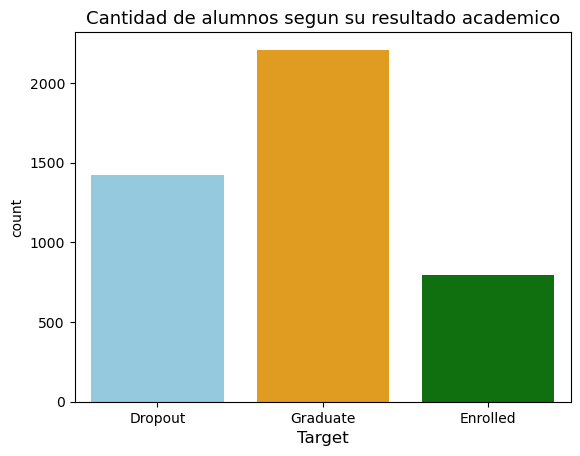

In [8]:
#el primer grafico de barras para ver la cantidad de alumnos por clase en el datases
sns.countplot(
    data=data,
    x='Target',
    hue='Target',
    palette=['skyblue', 'orange', 'green'],
    legend=False
)
plt.xlabel('Target', fontsize=12)
plt.title('Cantidad de alumnos segun su resultado academico', fontsize=13)
plt.show()

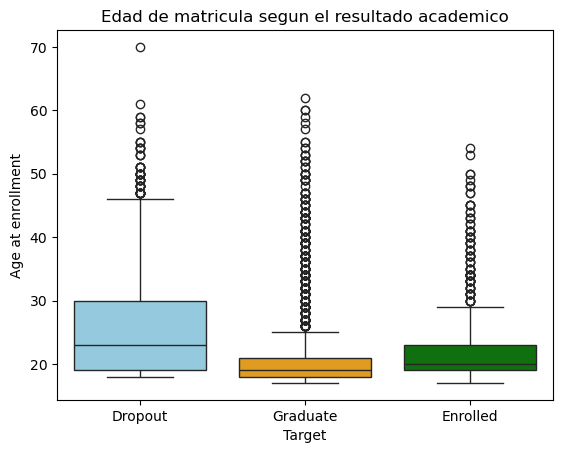

In [9]:
#esto para comparar la edad de matricula segun el resultado
sns.boxplot(
    x='Target', y='Age at enrollment', data=data,
    hue='Target',
    palette=['skyblue', 'orange', 'green'],
    legend=False
)
plt.title('Edad de matricula segun el resultado academico')
plt.show()

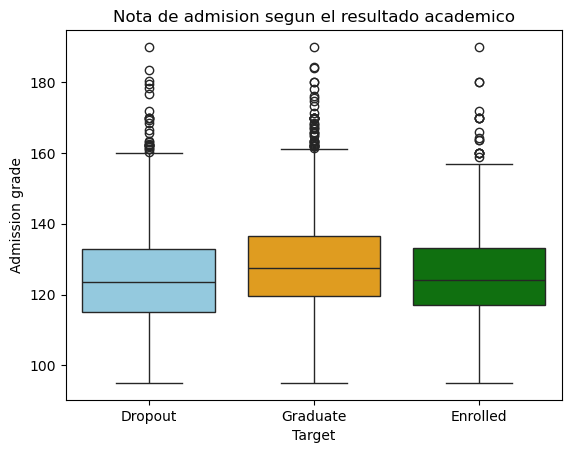

In [14]:
# grafico para comparar la nota de admision segun el resultado
sns.boxplot(
    x='Target', y='Admission grade', data=data,
    hue='Target',
    palette=['skyblue', 'orange', 'green'],
    legend=False
)
plt.title('Nota de admision segun el resultado academico')
plt.show()

Target              Dropout  Enrolled  Graduate
Scholarship holder                             
0                      1287       664      1374
1                       134       130       835


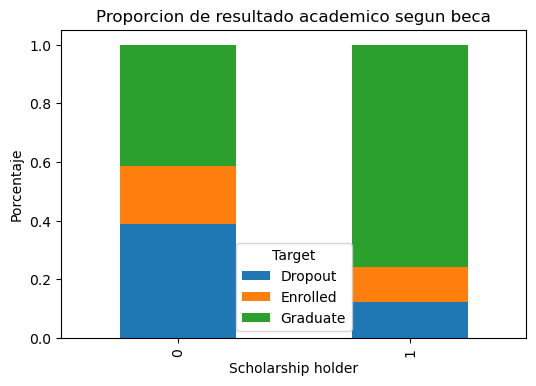

In [15]:
#par comparar becados con el resultado academico
tabla_becas = pd.crosstab(data['Scholarship holder'], data['Target'])
print(tabla_becas)

tabla_becas_porcentaje = tabla_becas.div(tabla_becas.sum(axis=1).astype(float), axis=0)
tabla_becas_porcentaje.plot(kind='bar', stacked=True, figsize=(6, 4))
plt.xlabel('Scholarship holder')
plt.ylabel('Porcentaje')
plt.title('Proporcion de resultado academico segun beca')
plt.legend(title='Target')
plt.show()

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


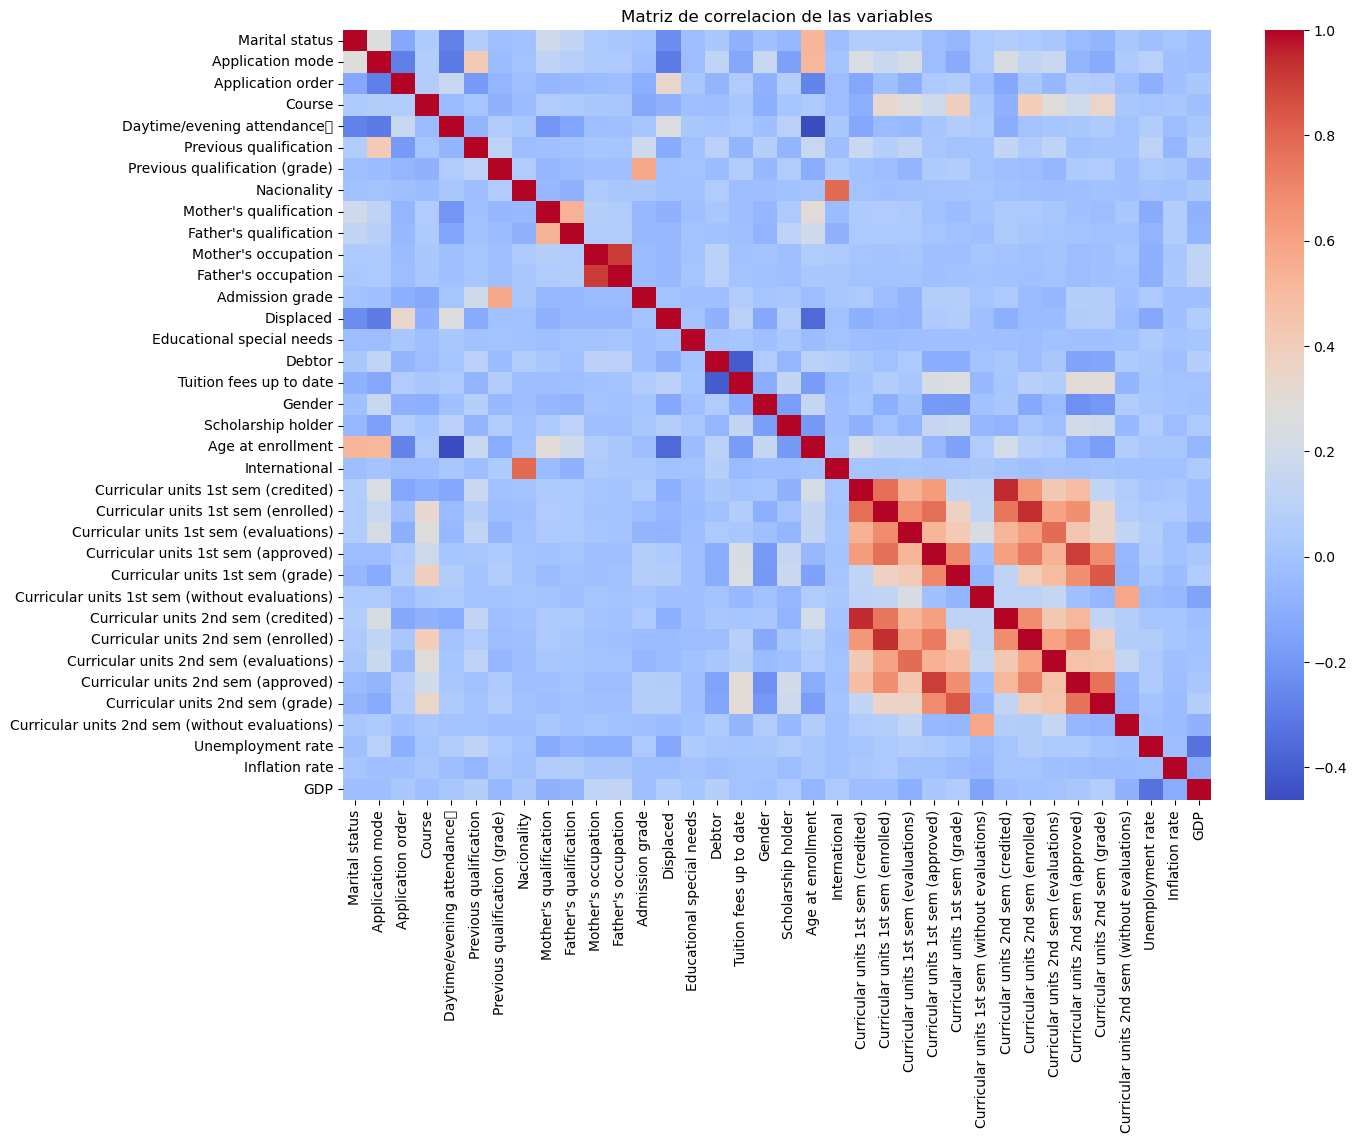

In [16]:
# matriz de correlacion de las variables numericas
plt.figure(figsize=(14, 10))
sns.heatmap(data.corr(numeric_only=True), cmap='coolwarm')
plt.title('Matriz de correlacion de las variables')
plt.show()

## preparar las variables

In [17]:
#veo q la variable target es texto entonces se convierte a numero para q nos ayude con el entrenamiento
le = LabelEncoder()
data['Target'] = le.fit_transform(data['Target'])

print('Clases codificadas ', list(le.classes_), '->', list(range(len(le.classes_))))
data[['Target']].head()

Clases codificadas  ['Dropout', 'Enrolled', 'Graduate'] -> [0, 1, 2]


,Target
0,0
1,2
2,0
3,2
4,2


In [18]:
#separo  las variables predictoras X y la variable objetivo y
X = data.drop('Target', axis=1)
y = data['Target']

In [19]:
# escalo los datos para que todas las variables tengan valores parecidos
# esto con el fim para que KNN funcione mejor porque usa distancias como hicmos en clase
escalador = StandardScaler()
X_escalado = escalador.fit_transform(X)

## division de datos para entrenamiento y prueba

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X_escalado, y, test_size=0.20, random_state=0
)

In [21]:
# reviso el tamaño de los conjuntos
print('Tamaño de entrenamiento ', X_train.shape)
print('Tamaño de prueba ', X_test.shape)

Tamano de entrenamiento  (3539, 36)
Tamano de prueba  (885, 36)


## modelo 1 KNN K Nearest Neighbors

In [22]:
# creo el modelo KNN con 5 vecinos
modelo_knn = KNeighborsClassifier(n_neighbors=5)
modelo_knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [23]:
# predicciones del modelo KNN sobre los datos de prueba
y_pred_knn = modelo_knn.predict(X_test)
y_pred_knn[0:5]

array([2, 0, 2, 1, 0])

In [24]:
# exactitud del modelo knn
exactitud_knn = accuracy_score(y_test, y_pred_knn)
print('Exactitud del modelo KNN ', exactitud_knn)

Exactitud del modelo KNN  0.7265536723163842


[[203  33  48]
 [ 43  48  60]
 [ 22  36 392]]


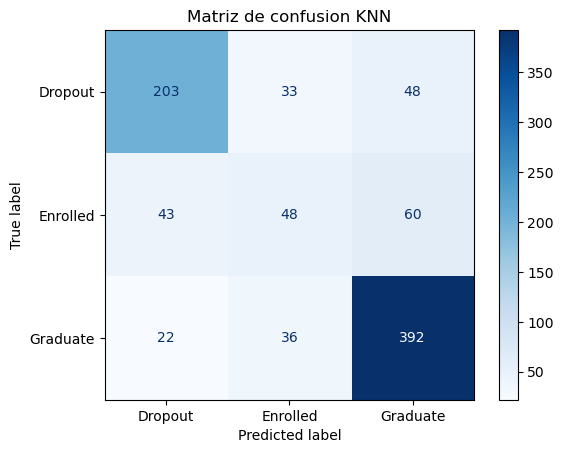

In [25]:
# matriz de confusion del modelo knn
matriz_knn = confusion_matrix(y_test, y_pred_knn)
print(matriz_knn)

disp = ConfusionMatrixDisplay(confusion_matrix=matriz_knn, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de confusion KNN')
plt.show()

## modelo 2 Naive Bayes Gaussian

In [26]:
# se crea el modelo naive bayes gaussiano
modelo_nb = GaussianNB()
modelo_nb.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [27]:
# predicciones del modelo naive bayes sobre los datos de prueba
y_pred_nb = modelo_nb.predict(X_test)
y_pred_nb[0:5]

array([2, 0, 2, 2, 0])

In [28]:
# exactitud del modelo naive bayes
exactitud_nb = accuracy_score(y_test, y_pred_nb)
print('Exactitud del modelo Naive Bayes ', exactitud_nb)

Exactitud del modelo Naive Bayes  0.6655367231638418


[[196  25  63]
 [ 34  19  98]
 [ 39  37 374]]


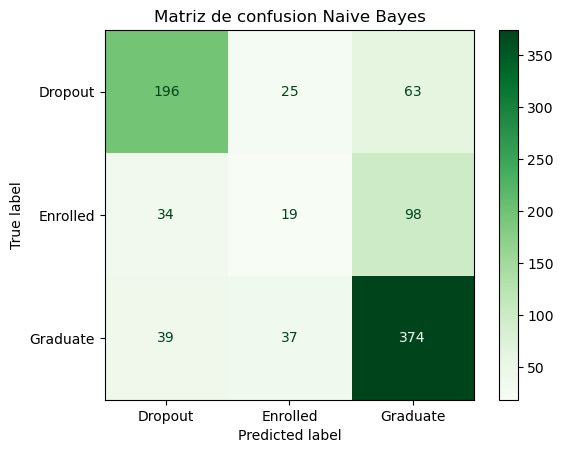

In [29]:
# matriz de confusion del modelo naive bayes
matriz_nb = confusion_matrix(y_test, y_pred_nb)
print(matriz_nb)

disp = ConfusionMatrixDisplay(confusion_matrix=matriz_nb, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Greens)
plt.title('Matriz de confusion Naive Bayes')
plt.show()

## curva ROC y AUC

In [30]:
# como la variable objetivo tiene 3 clases se debe binarizar pa poder calcular la curva roc de cada clase
clases = [0, 1, 2]
y_test_bin = label_binarize(y_test, classes=clases)

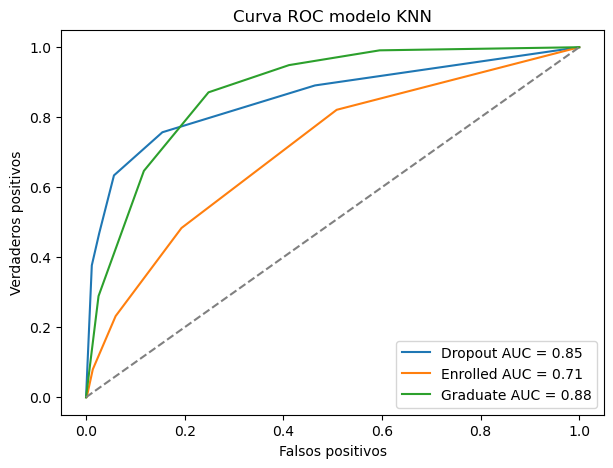

In [31]:
#probabilidades del modelo knn para cada clase
prob_knn = modelo_knn.predict_proba(X_test)

plt.figure(figsize=(7, 5))
for i in range(len(clases)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], prob_knn[:, i])
    valor_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=le.classes_[i] + ' AUC = ' + str(round(valor_auc, 2)))

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('Falsos positivos')
plt.ylabel('Verdaderos positivos')
plt.title('Curva ROC modelo KNN')
plt.legend()
plt.show()

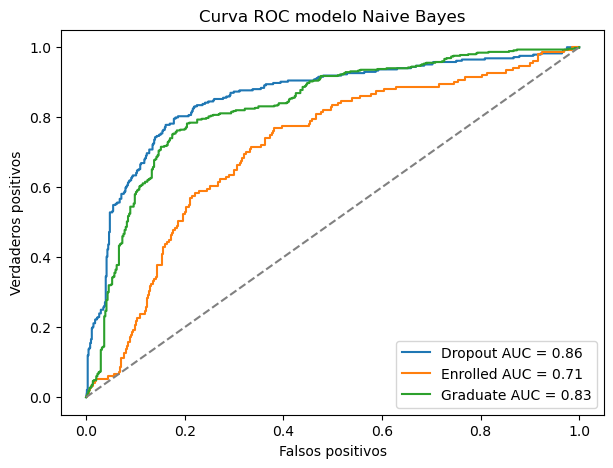

In [32]:
#las probabilidades del modelo naive bayes para cada clase
prob_nb = modelo_nb.predict_proba(X_test)

plt.figure(figsize=(7, 5))
for i in range(len(clases)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], prob_nb[:, i])
    valor_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=le.classes_[i] + ' AUC = ' + str(round(valor_auc, 2)))

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('Falsos positivos')
plt.ylabel('Verdaderos positivos')
plt.title('Curva ROC modelo Naive Bayes')
plt.legend()
plt.show()

In [33]:
#se calcula el auc promedio de cada modelo usando ovr one vs rest
auc_knn = roc_auc_score(y_test_bin, prob_knn, multi_class='ovr')
auc_nb = roc_auc_score(y_test_bin, prob_nb, multi_class='ovr')

print('AUC promedio KNN ', auc_knn)
print('AUC promedio Naive Bayes ', auc_nb)

AUC promedio KNN  0.813080942255997
AUC promedio Naive Bayes  0.8003284154524773


## conclusiones

uso el archivo csv porque venia con el separador correcto para trabajar en pandas ya q con la coma del txt no nos ayuda

El dataset tiene (4k y pico mas) 4424 de estudiantes y 36 caracteristicas sin datos nulos.

En el EDA se vio que los alumnos graduados tienden a tener mejor nota de admision

Los alumnos becados tienen un mayor proporcion de graduados que de abandono

Se entrenaron dos modelos KNN y Naive Bayes para predecir si el alumno abandona o continua matriculado o se gradua

Comparando la exactitud y el AUC de ambos modelos se puede ver cual clasifica mejor esta bace de datos

En este caso el modelo que obtuvo mejor AUC fue el que mejor logro separar las tres clases del problema